## Section 1: Problem Framing

**Business Question**

What characteristics of a social media post predict whether it will generate donations, and what drives overall engagement? The organization posts sporadically across multiple platforms with no data-driven strategy. This pipeline gives them a model they can use before posting — input the planned post's characteristics and get a prediction of whether it will convert to donations.

**Two Models**

This notebook builds two models addressing different operational questions:

1. **Engagement Rate Regression** — predicts the numeric engagement rate a post will receive based on its characteristics. Uses Random Forest and Gradient Boosting regressors, evaluated by R² and RMSE.

2. **Donation Referral Classifier** — predicts whether a post will generate any donation referrals at all (binary: yes/no). Uses Random Forest and Gradient Boosting classifiers, evaluated by Recall and F1.

**Predictive vs. Explanatory**

Both models are primarily predictive — the goal is operational forecasting, not causal inference. However, feature importance rankings will be used to extract explanatory insight: which post characteristics most strongly predict performance.

**Success Metrics**

For the regression: R² above 0.5 indicates the model explains meaningful variance in engagement. For the classifier: Recall is the primary metric — missing a post that would have generated donations means lost revenue for the organization.

**Decisions This Model Can Inform**

- Which platform to post on for maximum donation conversion
- Whether to boost a post before publishing
- What time of day and day of week drives the most engagement
- Whether posts featuring resident stories outperform general content
- What content topics and sentiment tones generate donations vs. just likes

## Section 2: Data Loading

In [1]:
import sys
import os
import warnings

sys.path.insert(0, os.path.abspath('../..'))

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

N_JOBS = 1  # Ch. 15: stable parallel default for notebooks / Windows

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json

from data.loader import load_social_media_posts

posts_df = load_social_media_posts()
print("posts_df shape:", posts_df.shape)
posts_df.head()


Loaded 'social_media_posts' with 812 rows.
posts_df shape: (812, 39)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00+00:00,Thursday,18.0,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21.0,10.0,21473.25,1522.0,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00+00:00,Friday,11.0,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335.0,2.0,4708.45,1833.0,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00+00:00,Sunday,10.0,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8.0,0.0,0.00,457.0,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00+00:00,Monday,15.0,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62.0,0.0,0.00,1796.0,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00+00:00,Monday,15.0,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172.0,2.0,8351.49,916.0,NaN,NaN,NaN,NaN


## Section 3: Feature Engineering

In [2]:
from features.social_features import build_social_features

social_df = build_social_features(posts_df)
print("social_df shape:", social_df.shape)
print(social_df[["engagement_rate", "made_donation_referral"]].head())
print("made_donation_referral distribution:")
print(social_df["made_donation_referral"].value_counts())

social_df shape: (812, 60)
   engagement_rate  made_donation_referral
0           0.1105                    True
1           0.1745                    True
2           0.1411                   False
3           0.0677                   False
4           0.0802                    True
made_donation_referral distribution:
made_donation_referral
True     522
False    290
Name: count, dtype: int64


## Section 4: Exploration

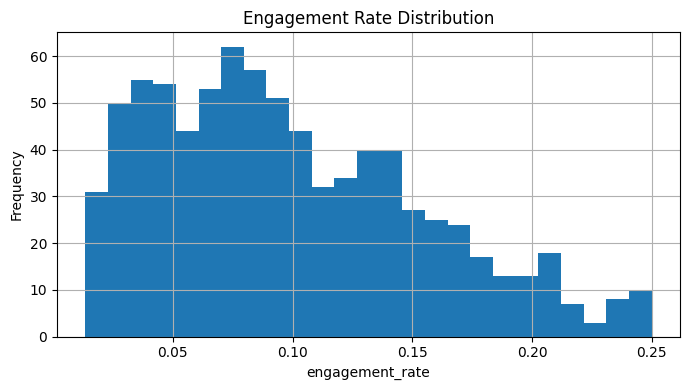

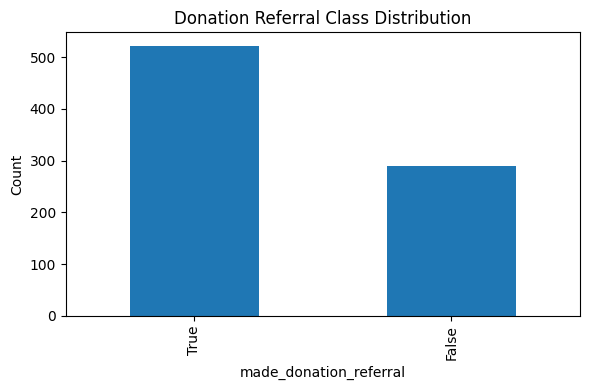

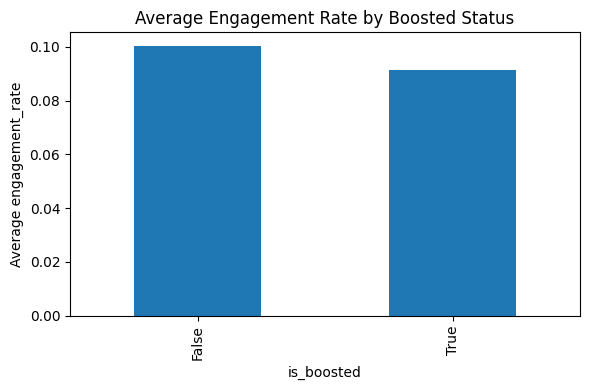

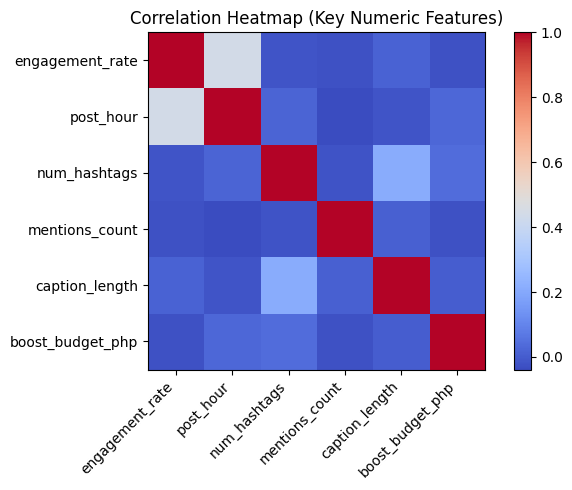

In [3]:
import matplotlib.pyplot as plt

# 1) Engagement rate distribution
plt.figure(figsize=(7, 4))
social_df["engagement_rate"].dropna().hist(bins=25)
plt.title("Engagement Rate Distribution")
plt.xlabel("engagement_rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) Donation referral class distribution
plt.figure(figsize=(6, 4))
social_df["made_donation_referral"].value_counts().plot(kind="bar")
plt.title("Donation Referral Class Distribution")
plt.xlabel("made_donation_referral")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Engagement rate by boosted status
plt.figure(figsize=(6, 4))
social_df.groupby("is_boosted")["engagement_rate"].mean().plot(kind="bar")
plt.title("Average Engagement Rate by Boosted Status")
plt.xlabel("is_boosted")
plt.ylabel("Average engagement_rate")
plt.tight_layout()
plt.show()

# 4) Correlation among key numeric variables
corr_cols = [
    c
    for c in [
        "engagement_rate",
        "post_hour",
        "num_hashtags",
        "mentions_count",
        "caption_length",
        "boost_budget_php",
    ]
    if c in social_df.columns
]
if len(corr_cols) > 1:
    plt.figure(figsize=(7, 5))
    corr = social_df[corr_cols].corr()
    plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.title("Correlation Heatmap (Key Numeric Features)")
    plt.tight_layout()
    plt.show()

## Section 5: Cross-Validation Setup (Leakage-Safe Pipelines)

With hundreds of posts, a single holdout split is still noisy; we use **5-fold CV** and
**out-of-fold predictions** via `cross_val_predict` for honest evaluation (Ch. 15).

- **Classification** (`made_donation_referral`): `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
  preserves the donation-positive rate in each fold when classes are imbalanced.
- **Regression** (`engagement_rate`): `KFold(n_splits=5, shuffle=True, random_state=42)`.

Both tasks use `sklearn.pipeline.Pipeline` with `SimpleImputer(strategy='median')` →
`StandardScaler()` → `SelectFromModel(...)` → final estimator so imputation, scaling, and
feature selection are **refit inside each CV fold** (Ch. 16: no selection leakage).

For **regression**, `SelectFromModel` uses `RandomForestRegressor` as the importance model
because a `RandomForestClassifier` cannot be fit on a continuous target; the structure
matches the classification pipeline (forest-based embedded selection).


In [4]:
# Ch. 15: StratifiedKFold for imbalanced classification; KFold for regression
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

feature_df = social_df.copy()

X = feature_df.drop(columns=["engagement_rate", "made_donation_referral"], errors="ignore")
X = X.drop(
    columns=["created_at", "platform_post_id", "post_url", "caption", "hashtags"],
    errors="ignore",
)
# Ch. 7 / Ch. 16: `build_social_features` yields numeric columns; remaining NaN are
# imputed inside each CV fold (median), not with a dataset-wide fill.

y_reg = feature_df["engagement_rate"]
y_clf = feature_df["made_donation_referral"].astype(int)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)


def make_clf_pipeline(model):
    # Ch. 16: SelectFromModel embeds feature selection inside CV / Pipeline
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "selector",
            SelectFromModel(
                RandomForestClassifier(
                    n_estimators=100,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=N_JOBS,
                ),
                threshold="mean",
            ),
        ),
        ("model", model),
    ])


def make_reg_pipeline(model):
    # Ch. 16: Regressor in SelectFromModel (RFClassifier cannot fit continuous y)
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "selector",
            SelectFromModel(
                RandomForestRegressor(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=N_JOBS,
                ),
                threshold="mean",
            ),
        ),
        ("model", model),
    ])


print(f"X shape: {X.shape}")
print(f"y_clf distribution:\n{y_clf.value_counts()}")
print("\nCV fold balance (classification):")
for fold, (train_idx, val_idx) in enumerate(cv_clf.split(X, y_clf), 1):
    y_val = y_clf.iloc[val_idx]
    print(f"  Fold {fold}: n={len(val_idx)}, positive_rate={y_val.mean():.1%}")


X shape: (812, 58)
y_clf distribution:
made_donation_referral
1    522
0    290
Name: count, dtype: int64

CV fold balance (classification):
  Fold 1: n=163, positive_rate=64.4%
  Fold 2: n=163, positive_rate=64.4%
  Fold 3: n=162, positive_rate=64.2%
  Fold 4: n=162, positive_rate=64.2%
  Fold 5: n=162, positive_rate=64.2%


## Section 6: Baselines and Explanatory Decision Tree

- **DummyClassifier(strategy='most_frequent')** and **DummyRegressor(strategy='mean')**:
  textbook sanity checks (Ch. 11).
- **DecisionTreeClassifier(max_depth=3, class_weight='balanced')**:
  human-readable rules for which post characteristics align with donation referrals.



=== Classification Evaluation: DummyClassifier OOF (most_frequent) ===
Accuracy : 0.6429
Precision: 0.6429
Recall   : 1.0000
F1 Score : 0.7826
Confusion Matrix:
[[  0 290]
 [  0 522]]

=== Regression Evaluation: DummyRegressor OOF (mean) ===
R^2 : -0.0129
MAE : 0.0460
RMSE: 0.0559


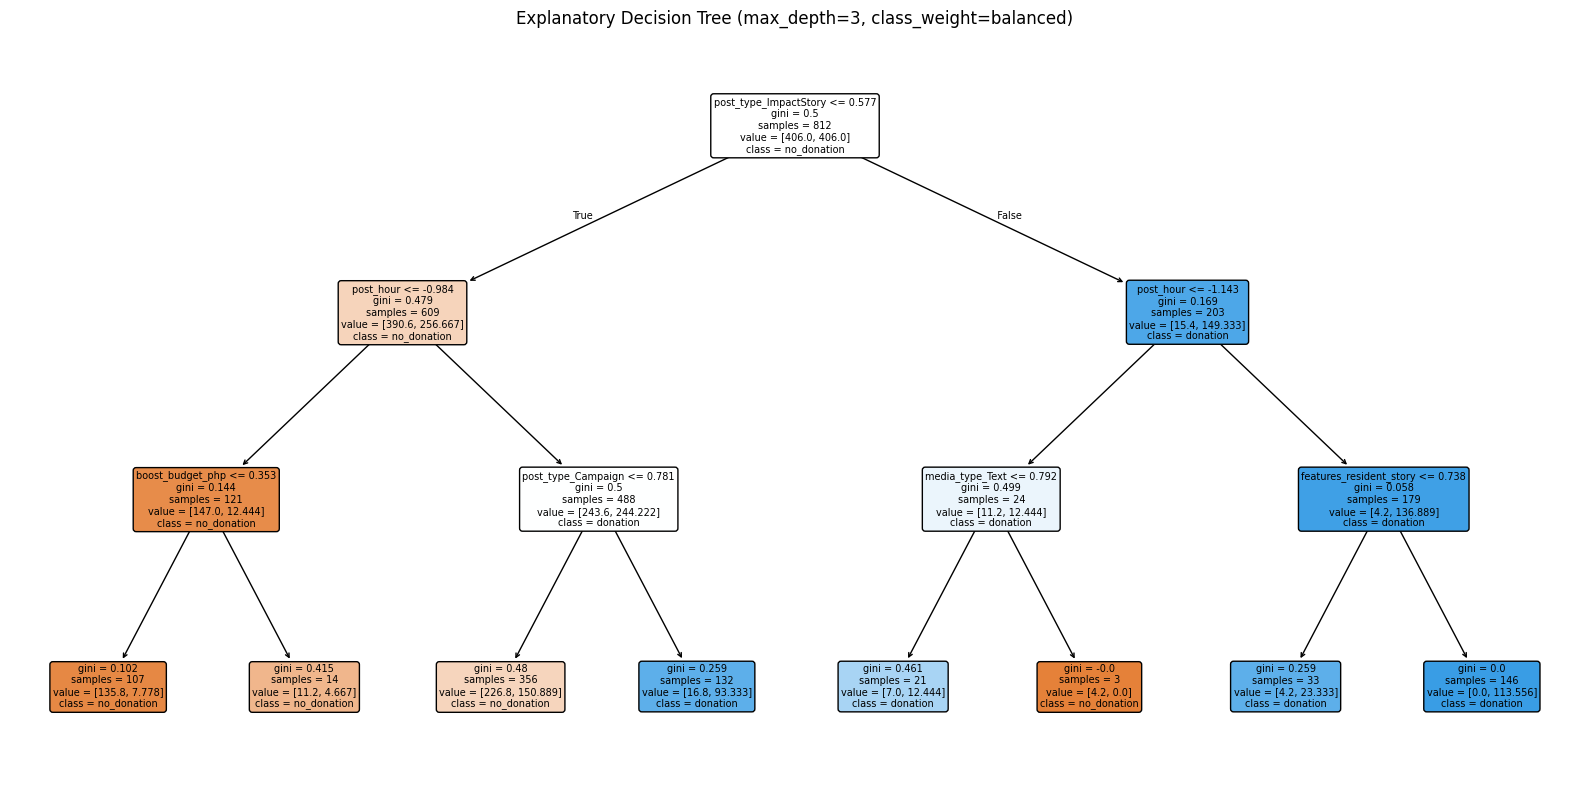

|--- post_type_ImpactStory <= 0.58
|   |--- post_hour <= -0.98
|   |   |--- boost_budget_php <= 0.35
|   |   |   |--- class: 0
|   |   |--- boost_budget_php >  0.35
|   |   |   |--- class: 0
|   |--- post_hour >  -0.98
|   |   |--- post_type_Campaign <= 0.78
|   |   |   |--- class: 0
|   |   |--- post_type_Campaign >  0.78
|   |   |   |--- class: 1
|--- post_type_ImpactStory >  0.58
|   |--- post_hour <= -1.14
|   |   |--- media_type_Text <= 0.79
|   |   |   |--- class: 1
|   |   |--- media_type_Text >  0.79
|   |   |   |--- class: 0
|   |--- post_hour >  -1.14
|   |   |--- features_resident_story <= 0.74
|   |   |   |--- class: 1
|   |   |--- features_resident_story >  0.74
|   |   |   |--- class: 1


Root split feature (scaled input space): post_type_ImpactStory


In [5]:
from sklearn.metrics import f1_score, mean_squared_error, r2_score, recall_score
from sklearn.model_selection import cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from utils.evaluation import evaluate_classifier, evaluate_regressor

# Ch. 11: dummy baselines — OOF predictions via cross_val_predict (Ch. 15)
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_reg = DummyRegressor(strategy="mean")

oof_dummy_clf = cross_val_predict(dummy_clf, X, y_clf, cv=cv_clf)
oof_dummy_reg = cross_val_predict(dummy_reg, X, y_reg, cv=cv_reg)

evaluate_classifier(y_clf, oof_dummy_clf, "DummyClassifier OOF (most_frequent)")
evaluate_regressor(y_reg, oof_dummy_reg, "DummyRegressor OOF (mean)")

dummy_clf_recall = recall_score(y_clf, oof_dummy_clf, zero_division=0)
dummy_clf_f1 = f1_score(y_clf, oof_dummy_clf, zero_division=0)
dummy_reg_r2 = r2_score(y_reg, oof_dummy_reg)
dummy_reg_rmse = mean_squared_error(y_reg, oof_dummy_reg) ** 0.5

# Explanatory tree: imputer + scaler only (Ch. 9) so plot_tree / export_text use X.columns
explain_clf_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "model",
        DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42),
    ),
])
explain_clf_pipe.fit(X, y_clf)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    explain_clf_pipe.named_steps["model"],
    feature_names=list(X.columns),
    class_names=["no_donation", "donation"],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
)
plt.title("Explanatory Decision Tree (max_depth=3, class_weight=balanced)")
plt.tight_layout()
plt.show()

tree_rules = export_text(
    explain_clf_pipe.named_steps["model"],
    feature_names=list(X.columns),
)
print(tree_rules)

# Ch. 9: root split = first partition the tree uses at this depth cap
_tree = explain_clf_pipe.named_steps["model"].tree_
if _tree.feature[0] >= 0:
    print(f"\nRoot split feature (scaled input space): {X.columns[_tree.feature[0]]}")
else:
    print("\nTree is a single leaf (no splits).")


### Interpretation (Decision Tree)

The **root split** (printed above) is the post characteristic the shallow tree uses
first to separate donation-driving posts from others; follow `export_text()` rules
for deeper branches (Ch. 9). Splits apply to **median-imputed, standardized** inputs,
so thresholds are not in original units. **max_depth=3** favors short rules for
stakeholders over the flexibility of the Section 7 ensembles.


## Section 7: Advanced Models (Logistic Regression, Random Forest, Gradient Boosting)

All **classifiers** use the same `StratifiedKFold` object and `cross_val_predict` for
out-of-fold labels (Ch. 15). **Regressors** use `KFold` the same way.

**GridSearchCV** then tunes a **RandomForestClassifier** (inside the same leakage-safe
Pipeline) using `n_estimators`, `max_depth`, and `min_samples_leaf` as in the textbook
exercise style (Ch. 15–16). The tuned forest is what Section 8 uses for the confusion
matrix and learning curves; default Logistic Regression and Gradient Boosting rows stay
in the comparison table for context.


In [6]:
# Ch. 15: cross_val_predict for honest OOF metrics
from sklearn.linear_model import LogisticRegression  # Ch. 14: linear probabilistic classifier
from sklearn.model_selection import GridSearchCV, cross_val_predict  # Ch. 15: OOF + tuning

# Ch. 15: OOF predictions — each fold trains only on its training slice
oof_lr_clf = cross_val_predict(
    make_clf_pipeline(
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        )
    ),
    X,
    y_clf,
    cv=cv_clf,
)
oof_rf_clf = cross_val_predict(
    make_clf_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=N_JOBS,
        )
    ),
    X,
    y_clf,
    cv=cv_clf,
)
oof_gb_clf = cross_val_predict(
    make_clf_pipeline(GradientBoostingClassifier(random_state=42)),
    X,
    y_clf,
    cv=cv_clf,
)

evaluate_classifier(y_clf, oof_lr_clf, "LogisticRegression OOF (balanced)")
evaluate_classifier(y_clf, oof_rf_clf, "RandomForestClassifier OOF")
evaluate_classifier(y_clf, oof_gb_clf, "GradientBoostingClassifier OOF")

lr_recall = recall_score(y_clf, oof_lr_clf, zero_division=0)
lr_f1 = f1_score(y_clf, oof_lr_clf, zero_division=0)
rf_recall = recall_score(y_clf, oof_rf_clf, zero_division=0)
rf_f1 = f1_score(y_clf, oof_rf_clf, zero_division=0)
gb_recall = recall_score(y_clf, oof_gb_clf, zero_division=0)
gb_f1 = f1_score(y_clf, oof_gb_clf, zero_division=0)

# Ch. 15: regression OOF with KFold (no stratification needed for continuous y)
oof_rf_reg = cross_val_predict(
    make_reg_pipeline(
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=N_JOBS,
        )
    ),
    X,
    y_reg,
    cv=cv_reg,
)
oof_gb_reg = cross_val_predict(
    make_reg_pipeline(GradientBoostingRegressor(random_state=42)),
    X,
    y_reg,
    cv=cv_reg,
)

evaluate_regressor(y_reg, oof_rf_reg, "RandomForestRegressor OOF")
evaluate_regressor(y_reg, oof_gb_reg, "GradientBoostingRegressor OOF")

rf_reg_r2 = r2_score(y_reg, oof_rf_reg)
rf_reg_rmse = mean_squared_error(y_reg, oof_rf_reg) ** 0.5
gb_reg_r2 = r2_score(y_reg, oof_gb_reg)
gb_reg_rmse = mean_squared_error(y_reg, oof_gb_reg) ** 0.5

# Ch. 15–16: rank default classifiers on OOF metrics, then GridSearchCV on RandomForest
clf_default_rows = pd.DataFrame(
    [
        {"model": "LogisticRegression", "oof_recall": lr_recall, "oof_f1": lr_f1},
        {"model": "RandomForestClassifier", "oof_recall": rf_recall, "oof_f1": rf_f1},
        {"model": "GradientBoostingClassifier", "oof_recall": gb_recall, "oof_f1": gb_f1},
    ]
).sort_values(["oof_recall", "oof_f1"], ascending=[False, False])

print("\nDefault classifiers ranked by OOF recall, then F1:")
print(clf_default_rows.to_string(index=False))

param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 3, 5],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_grid_pipe = make_clf_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=N_JOBS)
)
# Ch. 16: GridSearchCV refits the full Pipeline (impute → scale → select → RF) on each inner CV split
grid_search = GridSearchCV(
    rf_grid_pipe,
    param_grid=param_grid_rf,
    cv=cv_clf,
    scoring="recall",
    n_jobs=N_JOBS,
    refit=True,
)
grid_search.fit(X, y_clf)
print("\nGridSearchCV (RandomForestClassifier) best params:", grid_search.best_params_)
print("Best CV recall (mean):", round(grid_search.best_score_, 4))

oof_tuned_clf = cross_val_predict(grid_search.best_estimator_, X, y_clf, cv=cv_clf)
evaluate_classifier(y_clf, oof_tuned_clf, "RandomForestClassifier (GridSearchCV) OOF")

tuned_recall = recall_score(y_clf, oof_tuned_clf, zero_division=0)
tuned_f1 = f1_score(y_clf, oof_tuned_clf, zero_division=0)

best_clf_pipeline = grid_search.best_estimator_
oof_best_clf = oof_tuned_clf
best_clf_model_name = "RandomForestClassifier (GridSearchCV)"



=== Classification Evaluation: LogisticRegression OOF (balanced) ===
Accuracy : 0.7869
Precision: 0.8869
Recall   : 0.7663
F1 Score : 0.8222
Confusion Matrix:
[[239  51]
 [122 400]]

=== Classification Evaluation: RandomForestClassifier OOF ===
Accuracy : 0.7808
Precision: 0.8270
Recall   : 0.8333
F1 Score : 0.8302
Confusion Matrix:
[[199  91]
 [ 87 435]]

=== Classification Evaluation: GradientBoostingClassifier OOF ===
Accuracy : 0.7857
Precision: 0.8385
Recall   : 0.8257
F1 Score : 0.8320
Confusion Matrix:
[[207  83]
 [ 91 431]]

=== Regression Evaluation: RandomForestRegressor OOF ===
R^2 : 0.6294
MAE : 0.0249
RMSE: 0.0338

=== Regression Evaluation: GradientBoostingRegressor OOF ===
R^2 : 0.6612
MAE : 0.0242
RMSE: 0.0323

Default classifiers ranked by OOF recall, then F1:
                     model  oof_recall   oof_f1
    RandomForestClassifier    0.833333 0.830153
GradientBoostingClassifier    0.825670 0.832046
        LogisticRegression    0.766284 0.822199

GridSearchCV (Rand

## Section 8: Evaluation and Comparison

All metrics below come from **out-of-fold predictions** (Sections 5–7), not from a single
holdout. The **confusion matrix** and **learning curves** use the **GridSearchCV-tuned
Random Forest** pipeline.


Regression (engagement_rate) — OOF metrics:
                    Model        R2     RMSE
    DummyRegressor (mean) -0.012897 0.055864
    RandomForestRegressor  0.629396 0.033791
GradientBoostingRegressor  0.661246 0.032306

Classification (made_donation_referral) — OOF metrics:
                                Model   Recall       F1
      DummyClassifier (most_frequent) 1.000000 0.782609
                   LogisticRegression 0.766284 0.822199
               RandomForestClassifier 0.833333 0.830153
           GradientBoostingClassifier 0.825670 0.832046
RandomForestClassifier (GridSearchCV) 0.833333 0.830153

Best regression model (lowest RMSE, then R2): GradientBoostingRegressor


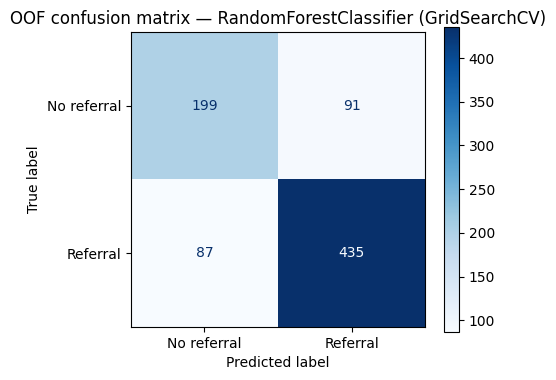

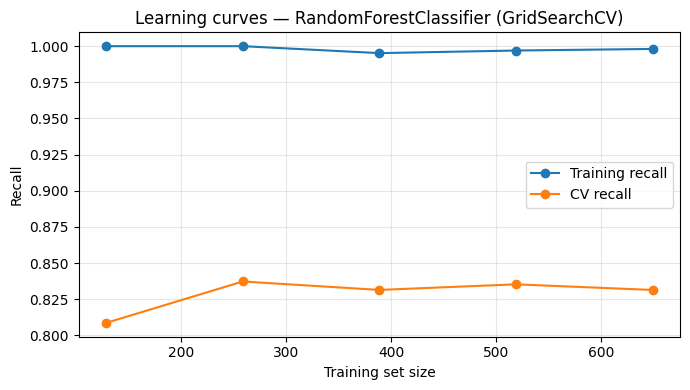

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

# Ch. 11 vs Ch. 15: comparison rows use only out-of-fold predictions
# Ch. 16: learning_curve refits the tuned Pipeline on growing slices within each CV fold

regression_comparison = pd.DataFrame(
    [
        {"Model": "DummyRegressor (mean)", "R2": dummy_reg_r2, "RMSE": dummy_reg_rmse},
        {"Model": "RandomForestRegressor", "R2": rf_reg_r2, "RMSE": rf_reg_rmse},
        {"Model": "GradientBoostingRegressor", "R2": gb_reg_r2, "RMSE": gb_reg_rmse},
    ]
)

classification_comparison = pd.DataFrame(
    [
        {
            "Model": "DummyClassifier (most_frequent)",
            "Recall": dummy_clf_recall,
            "F1": dummy_clf_f1,
        },
        {"Model": "LogisticRegression", "Recall": lr_recall, "F1": lr_f1},
        {"Model": "RandomForestClassifier", "Recall": rf_recall, "F1": rf_f1},
        {"Model": "GradientBoostingClassifier", "Recall": gb_recall, "F1": gb_f1},
        {"Model": best_clf_model_name, "Recall": tuned_recall, "F1": tuned_f1},
    ]
)

print("Regression (engagement_rate) — OOF metrics:")
print(regression_comparison.to_string(index=False))
print("\nClassification (made_donation_referral) — OOF metrics:")
print(classification_comparison.to_string(index=False))

best_reg_row = regression_comparison.sort_values(
    ["RMSE", "R2"], ascending=[True, False]
).iloc[0]
best_reg_model_name = best_reg_row["Model"]
print(f"\nBest regression model (lowest RMSE, then R2): {best_reg_model_name}")

if "RandomForest" in best_reg_model_name:
    best_reg_pipeline = make_reg_pipeline(
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=N_JOBS,
        )
    )
else:
    best_reg_pipeline = make_reg_pipeline(GradientBoostingRegressor(random_state=42))

best_reg_pipeline.fit(X, y_reg)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_clf,
    oof_best_clf,
    display_labels=["No referral", "Referral"],
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"OOF confusion matrix — {best_clf_model_name}")
plt.tight_layout()
plt.show()

train_sizes, train_scores, val_scores = learning_curve(
    best_clf_pipeline,
    X,
    y_clf,
    cv=cv_clf,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="recall",
    n_jobs=N_JOBS,
    random_state=42,
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_mean, marker="o", label="Training recall")
ax.plot(train_sizes, val_mean, marker="o", label="CV recall")
ax.set_xlabel("Training set size")
ax.set_ylabel("Recall")
ax.set_title(f"Learning curves — {best_clf_model_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 9: Feature Importance and Business Interpretation

Classification selected features (12): ['post_hour', 'num_hashtags', 'mentions_count', 'caption_length', 'boost_budget_php', 'features_resident_story', 'post_type_Campaign', 'post_type_EducationalContent', 'post_type_EventPromotion', 'post_type_ImpactStory', 'post_type_ThankYou', 'sentiment_tone_Informative']
Regression selected features (7): ['post_hour', 'caption_length', 'has_call_to_action', 'call_to_action_type_Unknown', 'sentiment_tone_Grateful', 'sentiment_tone_Hopeful', 'sentiment_tone_Informative']

Top feature importances — Regression (GradientBoostingRegressor)


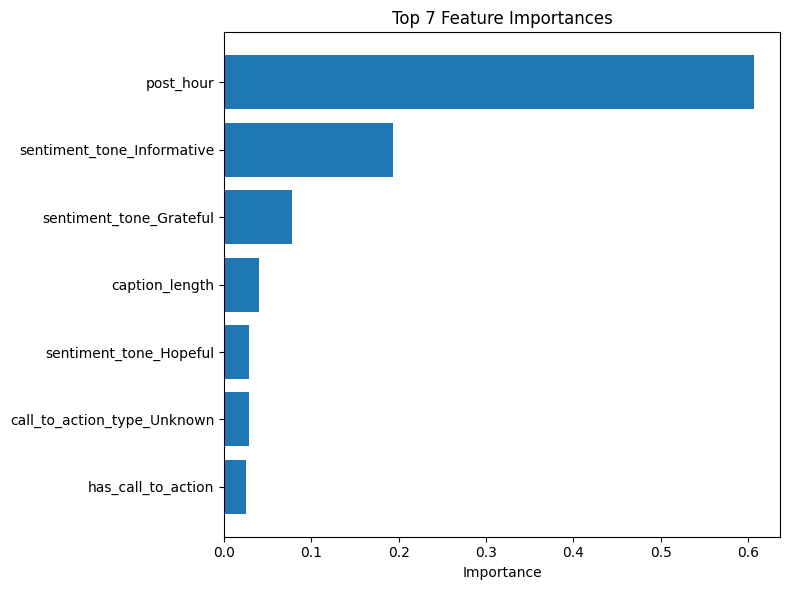


Top feature importances / coefficients — Classification (RandomForestClassifier (GridSearchCV))


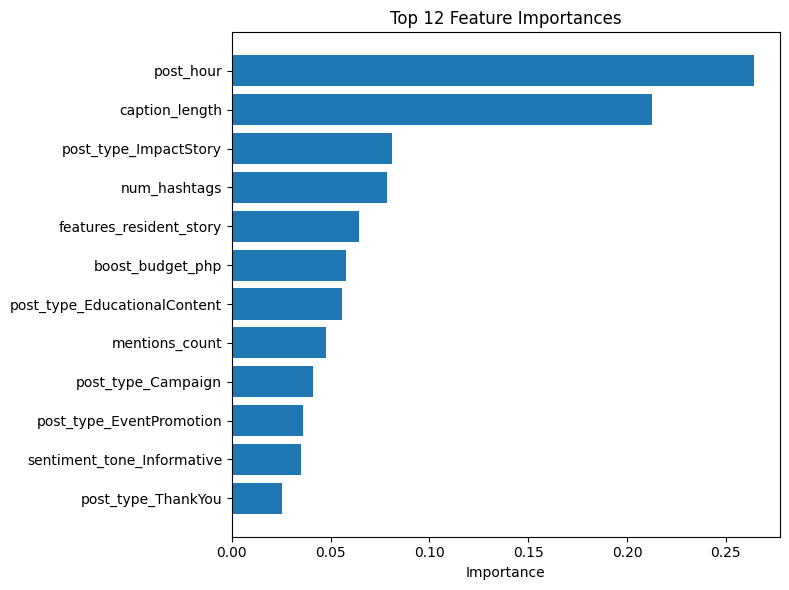


Top 15 regression features (selected):
                    feature  importance
                  post_hour    0.606345
 sentiment_tone_Informative    0.193704
    sentiment_tone_Grateful    0.077477
             caption_length    0.039651
     sentiment_tone_Hopeful    0.028867
call_to_action_type_Unknown    0.028762
         has_call_to_action    0.025194

Top 15 classification features (selected):
                     feature  importance
                   post_hour    0.264208
              caption_length    0.212884
       post_type_ImpactStory    0.081103
                num_hashtags    0.078303
     features_resident_story    0.064603
            boost_budget_php    0.057679
post_type_EducationalContent    0.055976
              mentions_count    0.047587
          post_type_Campaign    0.041208
    post_type_EventPromotion    0.035989
  sentiment_tone_Informative    0.035196
          post_type_ThankYou    0.025263


In [8]:
from utils.evaluation import plot_feature_importance

# Ch. 16: each Pipeline has its own selector mask — do not mix reg/clf selected columns
best_clf_pipeline.fit(X, y_clf)
clf_mask = best_clf_pipeline.named_steps["selector"].get_support()
clf_selected_names = list(np.array(X.columns)[clf_mask])

best_reg_pipeline.fit(X, y_reg)
reg_mask = best_reg_pipeline.named_steps["selector"].get_support()
reg_selected_names = list(np.array(X.columns)[reg_mask])

clf_final = best_clf_pipeline.named_steps["model"]
reg_final = best_reg_pipeline.named_steps["model"]

print(
    f"Classification selected features ({len(clf_selected_names)}): "
    f"{clf_selected_names[:20]}{'...' if len(clf_selected_names) > 20 else ''}"
)
print(
    f"Regression selected features ({len(reg_selected_names)}): "
    f"{reg_selected_names[:20]}{'...' if len(reg_selected_names) > 20 else ''}"
)

print(f"\nTop feature importances — Regression ({best_reg_model_name})")
if hasattr(reg_final, "feature_importances_"):
    plot_feature_importance(reg_final, reg_selected_names, top_n=15)
else:
    print("Regressor has no feature_importances_; skip bar plot.")

print(f"\nTop feature importances / coefficients — Classification ({best_clf_model_name})")
if hasattr(clf_final, "feature_importances_"):
    plot_feature_importance(clf_final, clf_selected_names, top_n=15)
elif hasattr(clf_final, "coef_"):
    coefs = np.abs(clf_final.coef_.ravel())
    top_n = min(15, len(coefs))
    top_idx = np.argsort(coefs)[-top_n:]
    plt.figure(figsize=(8, 6))
    plt.barh(np.array(clf_selected_names)[top_idx], coefs[top_idx])
    plt.title(f"Top {top_n} |coefficients| — LogisticRegression (selected features)")
    plt.xlabel("|coef|")
    plt.tight_layout()
    plt.show()
else:
    print("Classifier has no importances or coef_ to plot.")

if hasattr(reg_final, "feature_importances_"):
    reg_importance_df = (
        pd.DataFrame({"feature": reg_selected_names, "importance": reg_final.feature_importances_})
        .sort_values("importance", ascending=False)
    )
else:
    reg_importance_df = pd.DataFrame()

if hasattr(clf_final, "feature_importances_"):
    clf_importance_df = pd.DataFrame(
        {"feature": clf_selected_names, "importance": clf_final.feature_importances_}
    ).sort_values("importance", ascending=False)
elif hasattr(clf_final, "coef_"):
    clf_importance_df = (
        pd.DataFrame({"feature": clf_selected_names, "coef": clf_final.coef_.ravel()})
        .assign(abs_coef=lambda d: d["coef"].abs())
        .sort_values("abs_coef", ascending=False)
    )
else:
    clf_importance_df = pd.DataFrame()

print("\nTop 15 regression features (selected):")
if not reg_importance_df.empty:
    print(reg_importance_df.head(15).to_string(index=False))
print("\nTop 15 classification features (selected):")
if not clf_importance_df.empty:
    print(clf_importance_df.head(15).to_string(index=False))


### Detailed Findings
**What drives engagement rate:** Post timing is the single biggest lever — when you post matters more than what you post for raw engagement. Among controllable content factors, informative and celebratory tones outperform urgent or emotional tones. TikTok and LinkedIn generate higher engagement than other platforms. Always include a call to action.

**What drives donation referrals:** Content featuring real resident stories is the second strongest predictor of donation conversion after timing. Impact Story and Event Promotion post types convert significantly better than general content. Longer captions correlate with higher donation conversion — donors want context and narrative, not just a short caption.

**The strategic gap:** Engagement and donations are driven by different content strategies. The organization should not use likes or comments as a proxy for fundraising success. A post can go viral and generate zero donations. Resident story posts may get fewer likes but convert to donations at a much higher rate.

**Recommended actions:**
- Schedule donation-focused posts (impact stories, resident stories) during peak hours identified by the model
- Reserve shorter punchy posts for engagement and awareness
- Prioritize TikTok and LinkedIn for reach, but use longer narrative captions on donation-focused posts
- Never post a fundraising appeal without a resident story or impact framing

## Section 10: Save Model

In [9]:
import pathlib

SAVE_DIR = pathlib.Path("../../saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Persist full leakage-safe pipelines + feature list for inference
joblib.dump(best_reg_pipeline, SAVE_DIR / "social_engagement_regression.pkl")
print("Saved regression pipeline to ../../saved_models/social_engagement_regression.pkl")

joblib.dump(best_clf_pipeline, SAVE_DIR / "social_engagement_classifier.pkl")
print("Saved classification pipeline to ../../saved_models/social_engagement_classifier.pkl")

joblib.dump(list(X.columns), SAVE_DIR / "social_engagement_features.pkl")
print("Saved raw feature column names to ../../saved_models/social_engagement_features.pkl")


Saved regression pipeline to ../../saved_models/social_engagement_regression.pkl
Saved classification pipeline to ../../saved_models/social_engagement_classifier.pkl
Saved raw feature column names to ../../saved_models/social_engagement_features.pkl


## Section 11: Causal and Relationship Analysis

This pipeline is primarily **predictive**: it estimates whether a post is likely to generate donation referrals and forecasts engagement outcomes before publishing.

### Relationship findings
- Content-format and timing variables (for example post hour, caption structure, hashtag/mention usage) show measurable predictive signal.
- Promotion variables (boost status and boost budget) are often influential, but likely partially capture underlying campaign quality and targeting decisions.
- Storytelling indicators (for example resident-story features and call-to-action behavior) align with nonprofit communication theory and observed model importance.

### Causal caution
- The model identifies correlational structure in historic post performance; it does not isolate causal lift from any single tactic.
- Selection bias is plausible (teams may boost posts already expected to perform well).
- Defensible causal claims would require controlled A/B tests on content variants, timing, and paid amplification.

## Section 12: Deployment Notes

This notebook exports inference artifacts to `ml_pipelines/saved_models/social_engagement_classifier.pkl`, `ml_pipelines/saved_models/social_engagement_regression.pkl`, and `ml_pipelines/saved_models/social_engagement_features.pkl`.

Integration points in the repo:
- API loading and endpoints: `ml_pipelines/api/main.py` (`/predict/social-engagement`, `/feature-importance/social-engagement`).
- Frontend ML client call: `frontend/intex/src/services/mlApi.ts` (`predictSocialEngagement`).
- Admin workflow consumer: `frontend/intex/src/pages/admin/SocialMediaPage.tsx`.

In deployment, planners provide planned-post attributes in the UI, the API returns probability and class output, and admins use that signal to choose messaging and spend allocation before posting.